In [4]:
import numpy as np               # numerical computing library
import matplotlib.pyplot as plt  # plotting library
import os                        # operating system interface

os.chdir(r'C:/Users/Giannis/.vscode/02_monte_carlo_simulation_toolkit')  # set working directory

In [5]:
# Total number of random points to simulate for pi estimation
n_points = 100_000

# generate random x,y coordinates uniformly between -1 and 1

x = np.random.uniform(-1, 1, n_points)
y = np.random.uniform(-1, 1, n_points)

# calculate distance squared from origin for each point
# point is inside unit circle if x² + y² ≤ 1

distances = x**2 + y**2
inside = distances <= 1     # boolean array — True if point inside circle

# pi estimation — ratio of areas: circle/square = π/4
# therefore π ≈ 4 * (points inside circle / total points)

pi_estimate = 4 * np.sum(inside) / n_points

print(f'Points simulated:     {n_points:,}')        # format with comma separator
print(f'Points inside circle: {np.sum(inside):,}')
print(f'Pi estimate:          {pi_estimate:.6f}')   # 6 decimal places
print(f'Actual Pi:            {np.pi:.6f}')
print(f'Error:                {abs(pi_estimate - np.pi):.6f}')

Points simulated:     100,000
Points inside circle: 78,532
Pi estimate:          3.141280
Actual Pi:            3.141593
Error:                0.000313


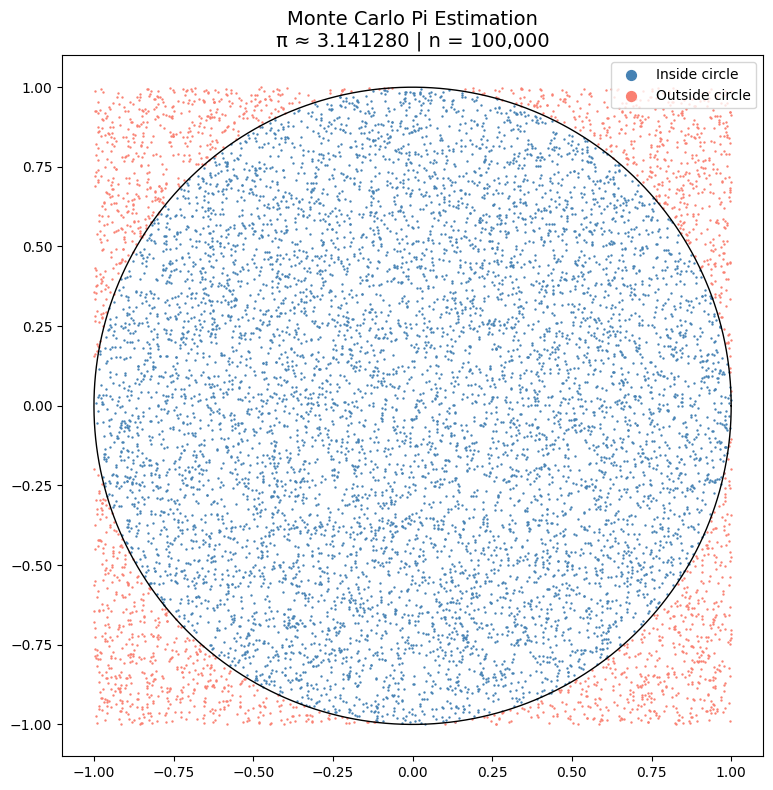

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))  # square figure for correct aspect ratio

sample = 10_000                         # plot subset only — 100,000 points would be too dense

# plot points inside circle in blue

ax.scatter(x[:sample][inside[:sample]], y[:sample][inside[:sample]],
           color='steelblue', s=0.5, label='Inside circle')

# plot points outside circle in red

ax.scatter(x[:sample][~inside[:sample]], y[:sample][~inside[:sample]],
           color='salmon', s=0.5, label='Outside circle')

# draw unit circle boundary using parametric equations

theta = np.linspace(0, 2*np.pi, 1000)                     # 1000 points around full circle
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1)  # circle outline

ax.set_aspect('equal')                                    # equal scaling so circle looks circular not elliptical
ax.set_title(f'Monte Carlo Pi Estimation\nπ ≈ {pi_estimate:.6f} | n = {n_points:,}',
             fontsize=14)
ax.legend(loc='upper right', markerscale=10)              # markerscale enlarges legend dots
plt.tight_layout()                                        # auto adjust spacing
plt.savefig('results/01_pi_estimation.png', bbox_inches='tight')  # save to results
plt.show()                                                # display plot

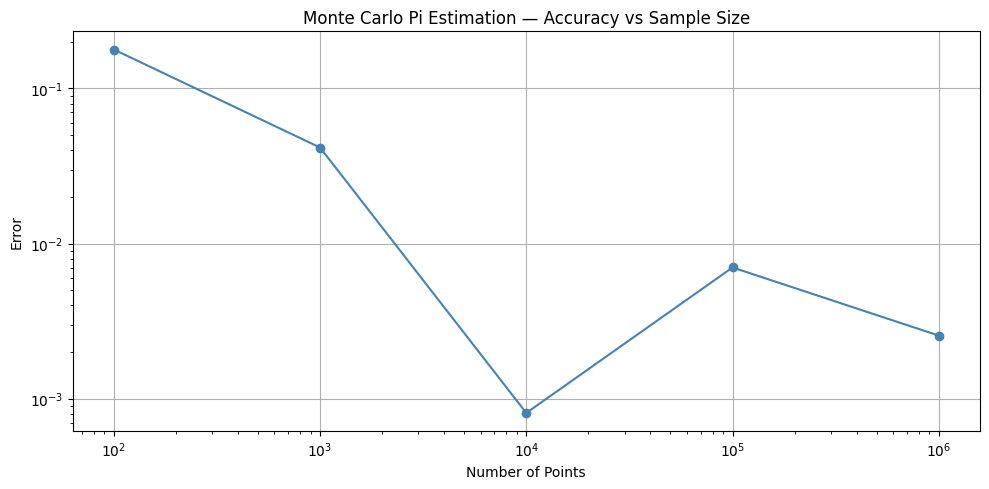

In [7]:
# test how accuracy improves with increasing number of points
sample_sizes = [100, 1_000, 10_000, 100_000, 1_000_000]  # powers of 10
errors = []  # store error for each sample size

for n in sample_sizes:
    x = np.random.uniform(-1, 1, n)      # random x coordinates
    y = np.random.uniform(-1, 1, n)      # random y coordinates
    inside = (x**2 + y**2) <= 1          # check if inside circle
    pi_est = 4 * np.sum(inside) / n      # estimate pi
    errors.append(abs(pi_est - np.pi))   # store absolute error

# log-log plot shows 1/√n convergence rate as a straight line
plt.figure(figsize=(10, 5))
plt.loglog(sample_sizes, errors, 'o-', color='steelblue')          # log scale both axes
plt.xlabel('Number of Points')           # x axis label
plt.ylabel('Error')                      # y axis label
plt.title('Monte Carlo Pi Estimation — Accuracy vs Sample Size')
plt.grid(True)                           # add grid
plt.tight_layout()                       # auto adjust spacing
plt.savefig('results/01_pi_convergence.png', bbox_inches='tight')  # save to results
plt.show()                               # display plot